# 02 — Parameter Estimation

In this notebook we move from **simulation** to **calibration**: given real market data, we estimate
the GBM parameters drift $\mu$ and volatility $\sigma$ from observed log-returns.

Under GBM, daily log-returns
$$
r_t = \log\frac{S_t}{S_{t-1}}
$$
are i.i.d.
$$
r_t \sim \mathcal{N}\!\left(\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t,\; \sigma^2 \Delta t\right).
$$

The **maximum likelihood estimators** (MLEs) of the GBM parameters from $n$ observed daily log-returns are:
$$
\hat{\mu} = \frac{\bar{r}}{\Delta t} + \frac{\hat{\sigma}^2}{2}, \qquad
\hat{\sigma}^2 = \frac{s^2}{\Delta t},
$$
where $\bar{r}$ is the sample mean of log-returns, $s^2$ is the sample variance, and $\Delta t = 1/252$.

We will:
1. Download SPY daily price data via `yfinance`
2. Compute and visualise log-returns
3. Estimate $\mu$ and $\sigma$ via MLE
4. Test the normality assumption empirically
5. Compute rolling volatility to study how $\sigma$ evolves over time
6. Compare implied vs realised volatility regimes

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# Consistent plot style across all notebooks
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [3]:
# Download Data
TICKER     = "SPY"          # S&P 500 ETF — change here to use any ticker
START_DATE = "2015-01-01"
END_DATE   = "2024-12-31"
DT         = 1 / 252        # one trading day in years

raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
prices = raw["Close"].dropna().squeeze()
prices.name = TICKER

print(f"Downloaded {len(prices):,} daily closing prices for {TICKER}")
print(f"Period : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nFirst five rows:")
print(prices.head())

Downloaded 2,515 daily closing prices for SPY
Period : 2015-01-02 → 2024-12-30

First five rows:
Date
2015-01-02    170.589600
2015-01-05    167.508804
2015-01-06    165.931076
2015-01-07    167.998749
2015-01-08    170.979919
Name: SPY, dtype: float64


In [4]:
# Compute Log-Returns
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"Number of daily log-returns : {len(log_returns):,}")
print(f"\nDescriptive statistics (daily log-returns):")
print(log_returns.describe().round(6))
print(f"\nSkewness  : {log_returns.skew():.4f}")
print(f"Kurtosis  : {log_returns.kurt():.4f}  (excess; normal = 0)")

Number of daily log-returns : 2,514

Descriptive statistics (daily log-returns):
count    2514.000000
mean        0.000488
std         0.011139
min        -0.115886
25%        -0.003712
50%         0.000597
75%         0.005911
max         0.086731
Name: SPY, dtype: float64

Skewness  : -0.8010
Kurtosis  : 13.6596  (excess; normal = 0)


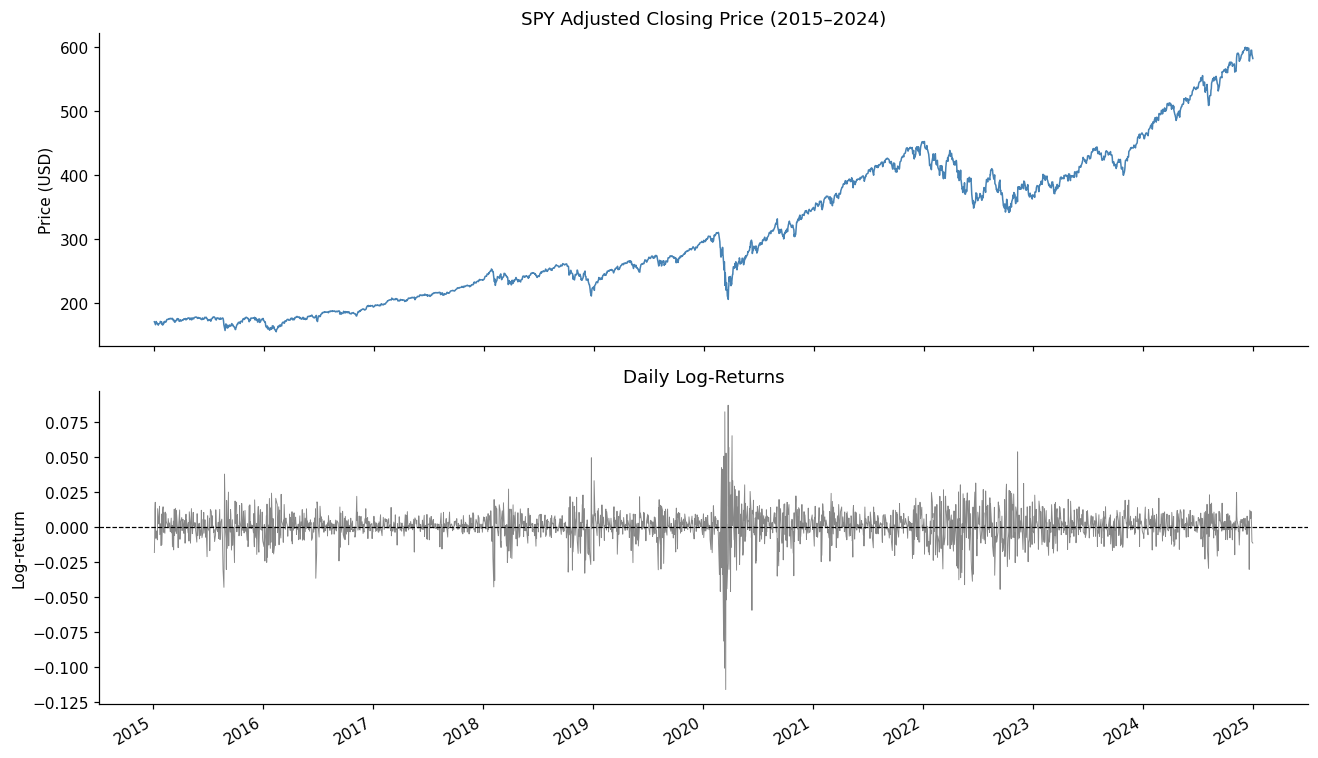

In [5]:
# Visualise Price History and Log-Returns 
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# Price history
axes[0].plot(prices.index, prices.values, linewidth=1, color="steelblue")
axes[0].set_title(f"{TICKER} Adjusted Closing Price ({START_DATE[:4]}–{END_DATE[:4]})")
axes[0].set_ylabel("Price (USD)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Daily log-returns
axes[1].plot(log_returns.index, log_returns.values, linewidth=0.6, color="dimgray", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Daily Log-Returns")
axes[1].set_ylabel("Log-return")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [6]:
# Maximum Likelihood Estimation of GBM Parameters
r     = log_returns.values          # numpy array for convenience
n     = len(r)

r_bar = r.mean()                    # sample mean of log-returns
s2    = r.var(ddof=1)               # sample variance (unbiased)

# Annualised MLE estimates
sigma_hat = np.sqrt(s2 / DT)        # annualised volatility
mu_hat    = r_bar / DT + 0.5 * sigma_hat**2   # annualised drift (Ito correction applied)

# Standard errors (delta method / asymptotic theory)
se_sigma  = sigma_hat / np.sqrt(2 * (n - 1))  # from chi-squared asymptotics
se_mu     = sigma_hat / np.sqrt(n * DT)        # standard error of mu_hat

print("=" * 50)
print(f"  MLE Parameter Estimates for {TICKER}")
print("=" * 50)
print(f"  Sample size (n)           : {n:,} trading days")
print(f"")
print(f"  Annualised drift  μ̂      : {mu_hat:.4f}  ({mu_hat*100:.2f}% p.a.)")
print(f"  Std error of μ̂           : ±{se_mu:.4f}")
print(f"")
print(f"  Annualised volatility σ̂  : {sigma_hat:.4f}  ({sigma_hat*100:.2f}% p.a.)")
print(f"  Std error of σ̂           : ±{se_sigma:.4f}")
print("=" * 50)

  MLE Parameter Estimates for SPY
  Sample size (n)           : 2,514 trading days

  Annualised drift  μ̂      : 0.1385  (13.85% p.a.)
  Std error of μ̂           : ±0.0560

  Annualised volatility σ̂  : 0.1768  (17.68% p.a.)
  Std error of σ̂           : ±0.0025


In [7]:
# Confidence Intervals for the Parameter Estimates
# 95% confidence interval for mu (normal approximation)
z95 = stats.norm.ppf(0.975)
mu_lo, mu_hi = mu_hat - z95 * se_mu, mu_hat + z95 * se_mu

# 95% CI for sigma using chi-squared distribution (exact, not approximate)
chi2_lo = stats.chi2.ppf(0.025, df=n - 1)
chi2_hi = stats.chi2.ppf(0.975, df=n - 1)
sigma_lo = np.sqrt((n - 1) * s2 / chi2_hi / DT)
sigma_hi = np.sqrt((n - 1) * s2 / chi2_lo / DT)

print(f"95% CI for μ  : [{mu_lo:.4f},  {mu_hi:.4f}]")
print(f"95% CI for σ  : [{sigma_lo:.4f},  {sigma_hi:.4f}]")
print()
print("Note: the wide CI for μ reflects the well-known difficulty of")
print("precisely estimating expected returns from historical data.")

95% CI for μ  : [0.0288,  0.2483]
95% CI for σ  : [0.1721,  0.1819]

Note: the wide CI for μ reflects the well-known difficulty of
precisely estimating expected returns from historical data.


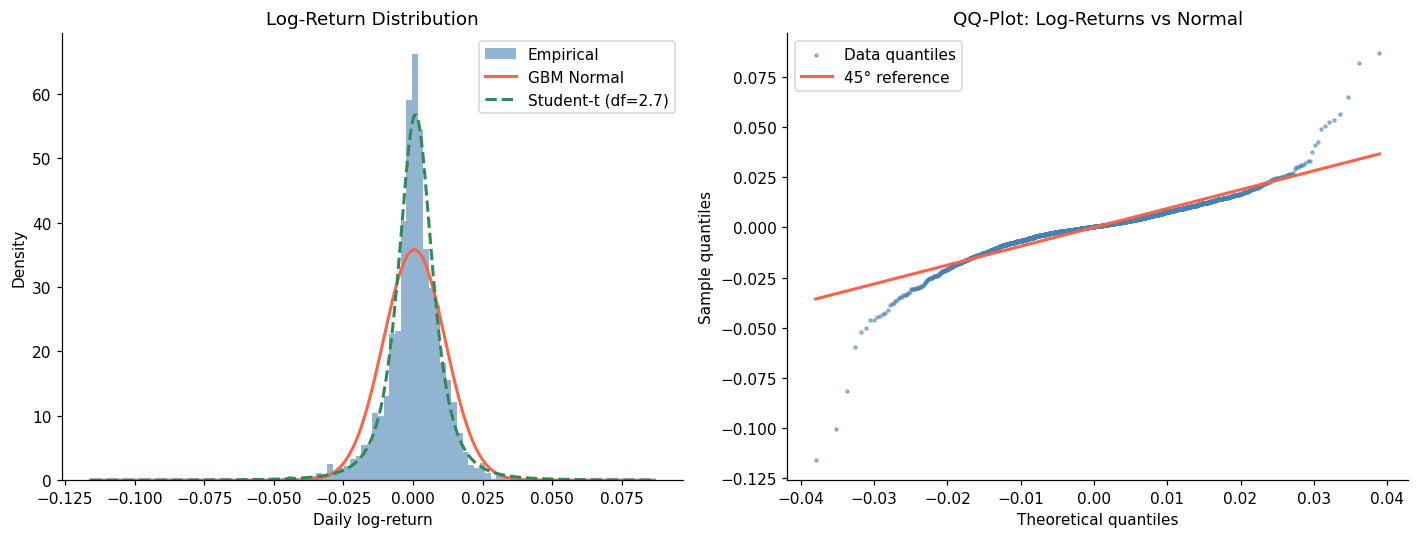

In [8]:
# Normality Diagnostics 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- (a) Histogram vs fitted normal ---
ax = axes[0]
theo_mean = (mu_hat - 0.5 * sigma_hat**2) * DT
theo_std  = sigma_hat * np.sqrt(DT)

ax.hist(r, bins=100, density=True, color="steelblue", alpha=0.6, label="Empirical")

grid = np.linspace(r.min(), r.max(), 500)
ax.plot(grid, stats.norm.pdf(grid, loc=theo_mean, scale=theo_std),
        linewidth=2, color="tomato", label="GBM Normal")

# Overlay a Student-t fit to highlight the fat tails GBM misses
df_t, loc_t, scale_t = stats.t.fit(r)
ax.plot(grid, stats.t.pdf(grid, df=df_t, loc=loc_t, scale=scale_t),
        linewidth=2, linestyle="--", color="seagreen", label=f"Student-t (df={df_t:.1f})")

ax.set_title("Log-Return Distribution")
ax.set_xlabel("Daily log-return")
ax.set_ylabel("Density")
ax.legend()

# --- (b) QQ-plot: empirical quantiles vs theoretical normal quantiles ---
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(r, dist="norm",
                                                     sparams=(theo_mean, theo_std))
ax.scatter(osm, osr, s=4, color="steelblue", alpha=0.5, label="Data quantiles")
line_x = np.array([osm.min(), osm.max()])
ax.plot(line_x, slope * line_x + intercept, color="tomato", linewidth=2, label="45° reference")
ax.set_title("QQ-Plot: Log-Returns vs Normal")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
# Formal Normality Tests
# Jarque-Bera: tests whether skewness and excess kurtosis jointly match a normal
jb_stat, jb_p = stats.jarque_bera(r)

# Kolmogorov-Smirnov: compares the full empirical CDF against the fitted normal
ks_stat, ks_p = stats.kstest(r, "norm", args=(theo_mean, theo_std))

print("Normality Tests on Daily Log-Returns")
print("-" * 45)
print(f"Jarque-Bera  stat={jb_stat:.2f},  p-value={jb_p:.2e}")
print(f"KS test      stat={ks_stat:.4f},  p-value={ks_p:.2e}")
print()
print("Both tests strongly reject normality, confirming that real")
print("log-returns have heavier tails than GBM predicts (a known")
print("limitation of the model).")

Normality Tests on Daily Log-Returns
---------------------------------------------
Jarque-Bera  stat=19728.79,  p-value=0.00e+00
KS test      stat=0.1063,  p-value=3.30e-25

Both tests strongly reject normality, confirming that real
log-returns have heavier tails than GBM predicts (a known
limitation of the model).


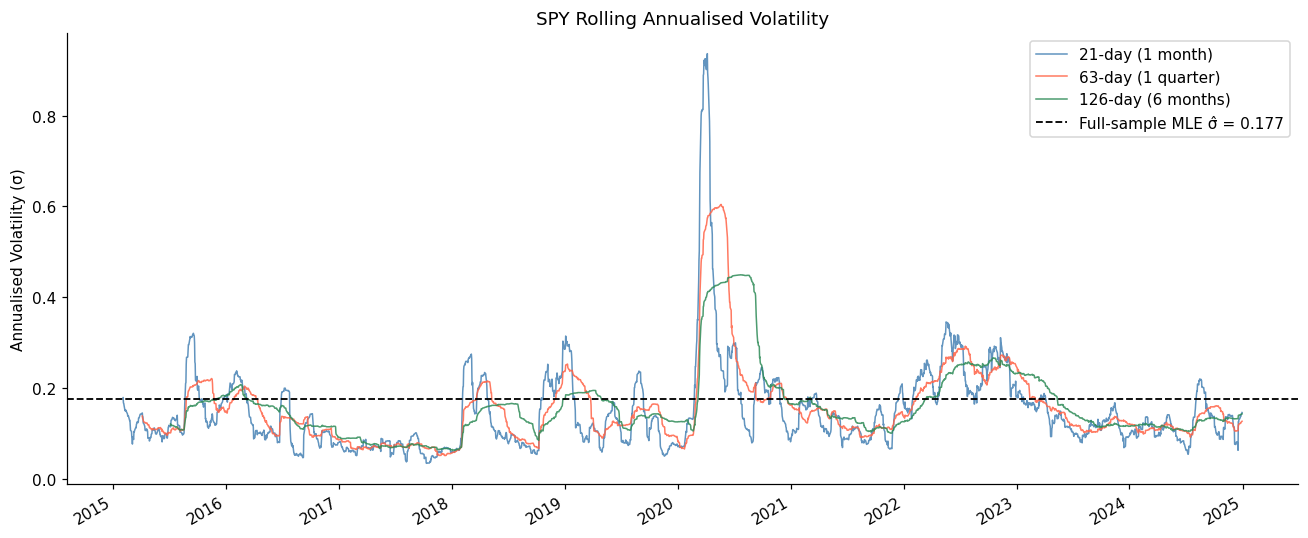

In [10]:
# Rolling Volatility 
# Annualised rolling volatility using different window lengths
windows = {"21-day (1 month)": 21, "63-day (1 quarter)": 63, "126-day (6 months)": 126}

fig, ax = plt.subplots(figsize=(12, 5))

colors = ["steelblue", "tomato", "seagreen"]
for (label, w), color in zip(windows.items(), colors):
    rolling_vol = log_returns.rolling(w).std() * np.sqrt(252)  # annualise by sqrt(252)
    ax.plot(rolling_vol.index, rolling_vol.values, linewidth=1,
            color=color, alpha=0.85, label=label)

# Full-sample constant volatility estimate as a flat reference line
ax.axhline(sigma_hat, color="black", linewidth=1.2, linestyle="--",
           label=f"Full-sample MLE σ̂ = {sigma_hat:.3f}")

ax.set_title(f"{TICKER} Rolling Annualised Volatility")
ax.set_ylabel("Annualised Volatility (σ)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.show()

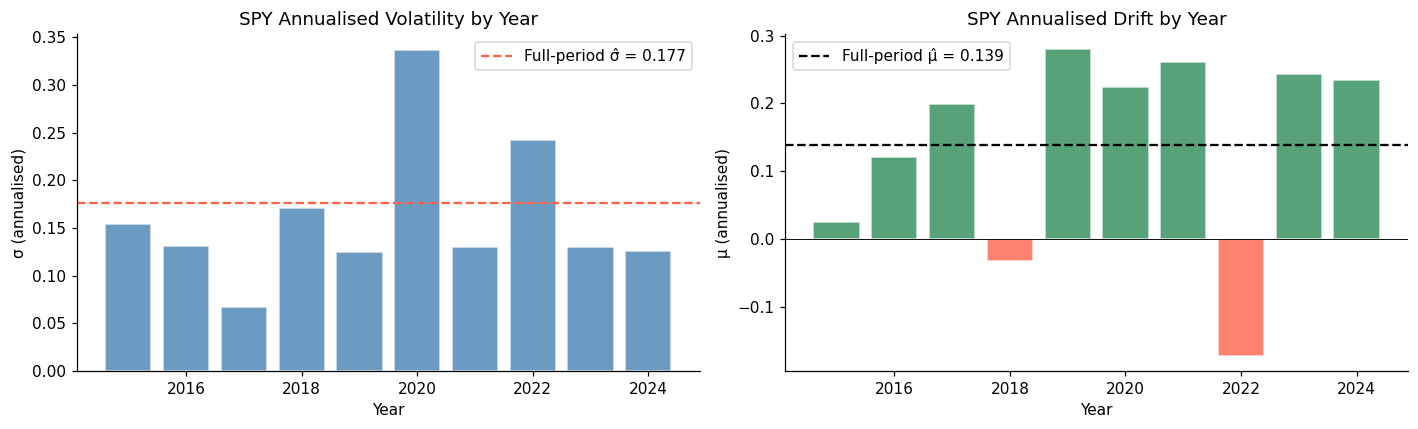

       sigma      mu
Date                
2015  0.1548  0.0248
2016  0.1308  0.1219
2017  0.0674  0.1995
2018  0.1708 -0.0324
2019  0.1253  0.2796
2020  0.3365  0.2243
2021  0.1299  0.2610
2022  0.2426 -0.1720
2023  0.1307  0.2429
2024  0.1260  0.2347


In [11]:
# Year-by-Year Volatility and Drift Decomposition 
# Estimate sigma and mu separately for each calendar year to see regime variation
yearly = (
    log_returns
    .groupby(log_returns.index.year)
    .agg(
        sigma=lambda x: x.std(ddof=1) * np.sqrt(252),
        mu=lambda x: (x.mean() / DT + 0.5 * (x.std(ddof=1) / np.sqrt(DT))**2)
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Annual volatility bar chart
axes[0].bar(yearly.index, yearly["sigma"], color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axhline(sigma_hat, color="tomato", linestyle="--", linewidth=1.5,
                label=f"Full-period σ̂ = {sigma_hat:.3f}")
axes[0].set_title(f"{TICKER} Annualised Volatility by Year")
axes[0].set_ylabel("σ (annualised)")
axes[0].set_xlabel("Year")
axes[0].legend()

# Annual drift bar chart — green for positive years, red for negative
bar_colors = ["seagreen" if v > 0 else "tomato" for v in yearly["mu"]]
axes[1].bar(yearly.index, yearly["mu"], color=bar_colors, alpha=0.8, edgecolor="white")
axes[1].axhline(mu_hat, color="black", linestyle="--", linewidth=1.5,
                label=f"Full-period μ̂ = {mu_hat:.3f}")
axes[1].axhline(0, color="black", linewidth=0.6)
axes[1].set_title(f"{TICKER} Annualised Drift by Year")
axes[1].set_ylabel("μ (annualised)")
axes[1].set_xlabel("Year")
axes[1].legend()

plt.tight_layout()
plt.show()

print(yearly.round(4))

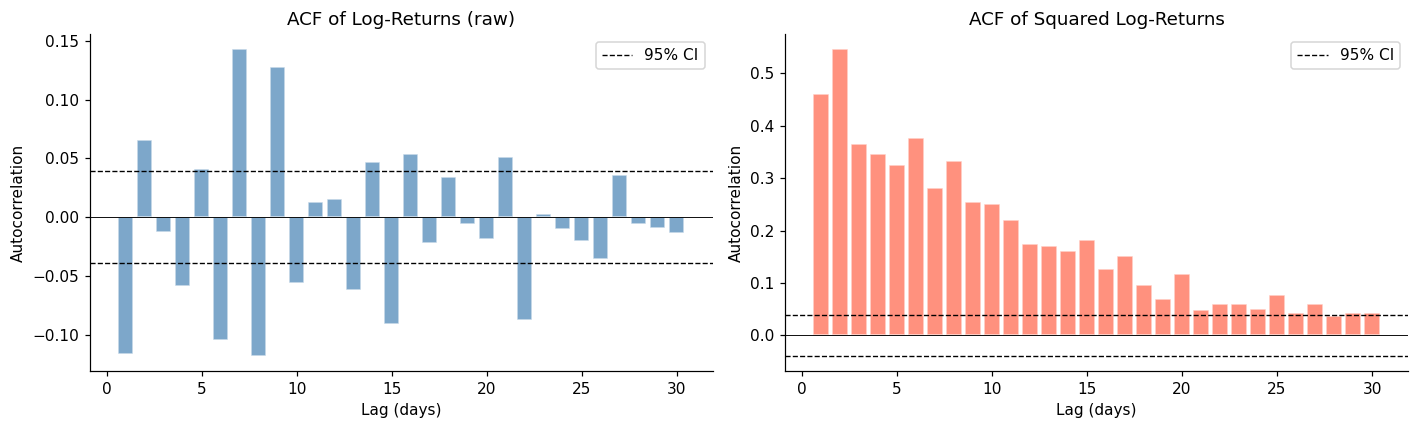

Interpretation:
  Raw returns     : near-zero autocorrelation → consistent with GBM i.i.d. assumption
  Squared returns : significant autocorrelation → volatility clustering (ARCH effects)
  This is a key empirical violation of the constant-σ GBM model.


In [12]:
# Autocorrelation: Are Returns Really IID?
# GBM assumes IID log-returns. We test this by inspecting autocorrelation
# of both raw returns and squared returns (a proxy for volatility clustering).

lags   = range(1, 31)
acf_r  = [log_returns.autocorr(lag=k) for k in lags]         # raw returns
acf_r2 = [(log_returns**2).autocorr(lag=k) for k in lags]    # squared returns (vol proxy)

# 95% confidence band for zero autocorrelation under the null hypothesis
conf = 1.96 / np.sqrt(len(log_returns))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, acf, title, color in zip(
    axes,
    [acf_r, acf_r2],
    ["ACF of Log-Returns (raw)", "ACF of Squared Log-Returns"],
    ["steelblue", "tomato"]
):
    ax.bar(list(lags), acf, color=color, alpha=0.7, edgecolor="white")
    ax.axhline( conf, linestyle="--", color="black", linewidth=0.9, label="95% CI")
    ax.axhline(-conf, linestyle="--", color="black", linewidth=0.9)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")
    ax.legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Raw returns     : near-zero autocorrelation → consistent with GBM i.i.d. assumption")
print("  Squared returns : significant autocorrelation → volatility clustering (ARCH effects)")
print("  This is a key empirical violation of the constant-σ GBM model.")

In [13]:
# Summary of Estimated Parameters
import json

summary = pd.DataFrame({
    "Parameter":    ["μ (drift, annualised)", "σ (volatility, annualised)"],
    "MLE Estimate": [round(mu_hat, 4),  round(sigma_hat, 4)],
    "Std Error":    [round(se_mu, 4),   round(se_sigma, 4)],
    "95% CI Lower": [round(mu_lo, 4),   round(sigma_lo, 4)],
    "95% CI Upper": [round(mu_hi, 4),   round(sigma_hi, 4)],
})

print("=" * 75)
print(f"  Final Estimated GBM Parameters for {TICKER} ({START_DATE[:4]}–{END_DATE[:4]})")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)
print()
print("These parameters will be used as inputs for option pricing in Notebook 03.")

# Save parameters to JSON so Notebook 03 can load them directly
params = {
    "ticker": TICKER,
    "s0":     float(prices.iloc[-1]),   # last observed price as starting point
    "mu":     round(mu_hat, 6),
    "sigma":  round(sigma_hat, 6),
    "start":  START_DATE,
    "end":    END_DATE
}
with open("estimated_params.json", "w") as f:
    json.dump(params, f, indent=2)

print("Parameters saved to estimated_params.json")

  Final Estimated GBM Parameters for SPY (2015–2024)
                 Parameter  MLE Estimate  Std Error  95% CI Lower  95% CI Upper
     μ (drift, annualised)        0.1385     0.0560        0.0288        0.2483
σ (volatility, annualised)        0.1768     0.0025        0.1721        0.1819

These parameters will be used as inputs for option pricing in Notebook 03.
Parameters saved to estimated_params.json
